# Tarefa 66 - Identificación de caras con DLIB

Crea un programa de consola que, dada una imagen con el rostro de una persona y su nombre, agregue el vector que identifica el rostro a un archivo (CSV, SQiIte, etc.), donde el nombre se asocia con el vector.

Este sistema de almacenamiento debería ser válido para su uso posterior en otros programas.

In [20]:
import cv2
from matplotlib import pyplot as plt

## DLIB

**Dlib** es un framework en C++ para IA que incluye herramientas para la detección y identificación de caras

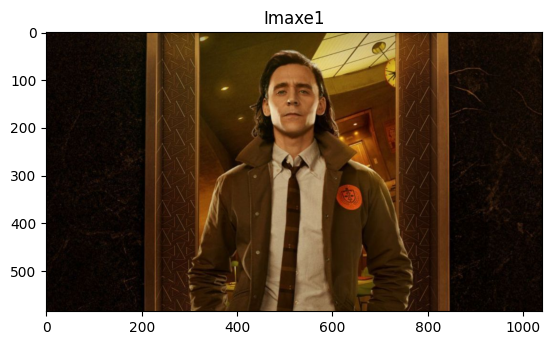

In [21]:
image = cv2.imread("img/loki.jpg")
imaxe_color = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(imaxe_color)
plt.title('Imaxe1')
plt.show()

Para trabajar con el detector de caras es preciso descargar:
- Un sistema para predecir la forma de posición de la cara: http://dlib.net/files/shape_predictor_5_face_landmarks.dat.bz2
- Una RNA para identificar la cara: http://dlib.net/files/dlib_face_recognition_resnet_model_v1.dat.bz2

In [22]:
import dlib
import numpy as np

predictor_path ="modelos/shape_predictor_5_face_landmarks.dat"
face_rec_model_path = "modelos/dlib_face_recognition_resnet_model_v1.dat"


detector = dlib.get_frontal_face_detector()
sp = dlib.shape_predictor(predictor_path)
facerec = dlib.face_recognition_model_v1(face_rec_model_path)


known_face_encodings = []
known_face_names = []

- Detectar a presenza de caras, chamando a **detector**
    - **detector** vai devolver un array cos rectángulos onde se detectou algo
- Para cada cara detectada:
    - Predecir a forma: chamdno ao **shape_predictor**, que antes se definiu como **sp**
    - Obter a firma da cara a partires da forma: chamar face_recognition_model_v1, definido como **facerec**

In [23]:
imaxePhill = cv2.imread("img/loki.jpg")
imaxePhillColor = cv2.cvtColor(imaxePhill, cv2.COLOR_BGR2RGB)

dets = detector(imaxePhill, 1)
print("Number of faces detected: {}".format(len(dets)))
posicions = dets[0]
display(posicions)
shape = sp(imaxePhill,posicions)

# Vector que se guarda para la cara conocida
face_descriptor = np.array(facerec.compute_face_descriptor(imaxePhill, shape))
display(face_descriptor)

known_face_encodings.append((face_descriptor,"Loki"))

Number of faces detected: 1


rectangle(462,92,569,199)

array([-2.07966659e-02,  1.32065669e-01,  8.35936666e-02, -4.10287306e-02,
       -8.06896165e-02, -1.73652228e-02, -1.60699598e-02, -1.15684733e-01,
        1.46648556e-01, -3.27374600e-02,  1.90741837e-01, -2.16839369e-04,
       -2.32620209e-01,  8.34507868e-02, -2.28753723e-02,  8.13403204e-02,
       -1.45684317e-01, -1.38786569e-01, -1.21226937e-01, -3.83222550e-02,
        3.75848799e-03,  9.38193798e-02,  2.34239828e-02,  1.70431603e-02,
       -1.85875252e-01, -1.84011891e-01, -9.73358005e-02, -1.49771914e-01,
       -1.79006308e-02, -1.23660140e-01,  2.65730824e-03,  3.80370058e-02,
       -2.14009479e-01, -1.00058779e-01,  5.43539003e-02, -2.45976336e-02,
       -8.06447342e-02, -6.52301088e-02,  2.15436563e-01,  9.47124362e-02,
       -1.81967258e-01,  4.99106310e-02,  1.18363038e-01,  3.07428271e-01,
        1.78694457e-01,  3.43303569e-02, -2.59628352e-02, -1.76076815e-02,
        9.12538767e-02, -2.57853955e-01,  1.49831384e-01,  9.92220119e-02,
        1.92009822e-01,  

## Solución final:

In [24]:
import pandas as pd
import os
import dlib
import numpy as np

predictor_path ="modelos/shape_predictor_5_face_landmarks.dat"
face_rec_model_path = "modelos/dlib_face_recognition_resnet_model_v1.dat"

detector = dlib.get_frontal_face_detector()
sp = dlib.shape_predictor(predictor_path)
facerec = dlib.face_recognition_model_v1(face_rec_model_path)

def obtenerVectorCaraImagen(imgPill):
    dets = detector(imgPill, 1)
    
    # Pequeña protección por si en la foto no se detecta ninguna cara
    if len(dets) == 0:
        print("No se detectó ninguna cara en la imagen.")
        return None
        
    print("Number of faces detected: {}".format(len(dets)))
    posicions = dets[0]
    display(posicions)
    
    shape = sp(imgPill, posicions)

    face_descriptor = np.array(facerec.compute_face_descriptor(imgPill, shape))
    display(face_descriptor)
    return face_descriptor

def guardarVectorCaraConNombre(nombre, face_descriptor):
    fingerprint_str = ",".join(face_descriptor.astype(str))
    
    nuevo_dato = pd.DataFrame(data={'nome': [nombre], 'fingerprint': [fingerprint_str]})
    
    # Comprobar si archivo existe
    if os.path.isfile('carasConocidas.csv'):
        # Leemos la base de datos actual
        df_existente = pd.read_csv('carasConocidas.csv')
        
        # Si el nombre ya está en la columna 'nome', paramos la función
        if nombre in df_existente['nome'].values:
            print(f"La cara de '{nombre}' ya existe. Se omite el guardado.")
            return
            
        # Si el archivo existe pero el nombre es nuevo, lo añadimos
        nuevo_dato.to_csv('carasConocidas.csv', mode='a', header=False, index=False)
    else:
        # Si el archivo no existe, lo creamos desde cero con sus cabeceras
        nuevo_dato.to_csv('carasConocidas.csv', index=False)
        
    print(f"Vector de '{nombre}' guardado correctamente en formato Pandas.")
        
imgLoki = cv2.imread("img/loki.jpg")
vectorLoki = obtenerVectorCaraImagen(imgLoki)
guardarVectorCaraConNombre("Loki",vectorLoki)

tedMosby = cv2.imread("img/tedDef.jpg")
vectorTedMosby = obtenerVectorCaraImagen(tedMosby)
guardarVectorCaraConNombre("Ted Mosby",vectorTedMosby)

imgBarney = cv2.imread("img/barney.jpg")
vectorBarney = obtenerVectorCaraImagen(imgBarney)
guardarVectorCaraConNombre("Barney Stinson",vectorBarney)

Number of faces detected: 1


rectangle(462,92,569,199)

array([-2.07966659e-02,  1.32065669e-01,  8.35936666e-02, -4.10287306e-02,
       -8.06896165e-02, -1.73652228e-02, -1.60699598e-02, -1.15684733e-01,
        1.46648556e-01, -3.27374600e-02,  1.90741837e-01, -2.16839369e-04,
       -2.32620209e-01,  8.34507868e-02, -2.28753723e-02,  8.13403204e-02,
       -1.45684317e-01, -1.38786569e-01, -1.21226937e-01, -3.83222550e-02,
        3.75848799e-03,  9.38193798e-02,  2.34239828e-02,  1.70431603e-02,
       -1.85875252e-01, -1.84011891e-01, -9.73358005e-02, -1.49771914e-01,
       -1.79006308e-02, -1.23660140e-01,  2.65730824e-03,  3.80370058e-02,
       -2.14009479e-01, -1.00058779e-01,  5.43539003e-02, -2.45976336e-02,
       -8.06447342e-02, -6.52301088e-02,  2.15436563e-01,  9.47124362e-02,
       -1.81967258e-01,  4.99106310e-02,  1.18363038e-01,  3.07428271e-01,
        1.78694457e-01,  3.43303569e-02, -2.59628352e-02, -1.76076815e-02,
        9.12538767e-02, -2.57853955e-01,  1.49831384e-01,  9.92220119e-02,
        1.92009822e-01,  

La cara de 'Loki' ya existe. Se omite el guardado.
Number of faces detected: 1


rectangle(408,133,562,288)

array([-1.42893404e-01,  9.13746357e-02,  9.22534093e-02,  2.48110387e-02,
       -1.06869921e-01, -3.43220942e-02, -4.09089997e-02, -7.63040259e-02,
        1.30630285e-01, -7.39839971e-02,  1.68835849e-01, -6.88878223e-02,
       -2.24011332e-01,  1.18591229e-03, -1.56640857e-02,  1.98587954e-01,
       -1.34341612e-01, -1.38867453e-01, -4.04690355e-02, -7.67921656e-02,
        2.88619529e-02,  1.00057468e-01, -1.29787493e-02,  1.54085979e-02,
       -1.32465020e-01, -3.20033550e-01, -3.87272835e-02, -1.20305523e-01,
        7.87803531e-02, -2.79174335e-02, -7.75837600e-02, -5.88822411e-04,
       -1.46121144e-01, -5.31472191e-02,  7.65860900e-02,  6.02167472e-02,
       -3.17421481e-02, -4.78348993e-02,  2.31978908e-01,  5.99705353e-02,
       -1.71550900e-01, -4.50347066e-02,  6.50328696e-02,  2.94174969e-01,
        9.46642831e-02,  3.51707861e-02,  8.27599317e-02, -1.27645567e-01,
        1.23363785e-01, -2.73731917e-01,  1.30210355e-01,  1.17808081e-01,
        8.28188658e-02,  

La cara de 'Ted Mosby' ya existe. Se omite el guardado.
Number of faces detected: 1


rectangle(175,66,265,156)

array([-7.93411806e-02,  1.23084404e-01,  4.29373942e-02, -6.98688924e-02,
       -1.13020636e-01, -1.63243026e-01,  8.54218379e-05, -4.23302464e-02,
        7.00512081e-02,  2.08306573e-02,  3.03872675e-01,  1.26503278e-02,
       -2.33021677e-01, -1.76047608e-01,  7.75051210e-03,  1.64284676e-01,
       -1.50606975e-01, -1.49773136e-01, -1.03979416e-01, -2.83470489e-02,
        3.26199457e-02,  1.05158230e-02,  5.03613539e-02, -1.88036337e-02,
       -3.67447399e-02, -3.15463543e-01, -6.72702864e-02, -5.70060760e-02,
        1.50114179e-01, -1.31259814e-01,  4.62640785e-02,  1.29019171e-01,
       -1.87459528e-01, -1.24028243e-01,  6.75088391e-02,  8.06020200e-02,
       -8.66296813e-02, -9.64119509e-02,  2.58999169e-01,  1.90153196e-02,
       -1.63295016e-01,  2.36333581e-03,  1.89495571e-02,  3.09509873e-01,
        2.63318539e-01, -2.75505967e-02,  9.39342976e-02, -4.87635732e-02,
        7.32405931e-02, -2.48808533e-01,  6.38821274e-02,  1.33902803e-01,
        1.37893289e-01,  

La cara de 'Barney Stinson' ya existe. Se omite el guardado.


In [25]:
## leer dataset csv
leido = pd.read_csv("carasConocidas.csv")
display(leido)
# Creamos nueva columna obteniendo el numpy formateado
leido["f2"] = leido.apply(lambda row: np.array(row['fingerprint'].split(',')).astype(np.float64), axis=1)

,nome,fingerprint
0,Loki,"-0.02079666592180729,0.13206566870212555,0.083..."
1,Ted Mosby,"-0.14289340376853943,0.09137463569641113,0.092..."
2,Barney Stinson,"-0.07934118062257767,0.1230844035744667,0.0429..."


In [26]:
display(leido)

,nome,fingerprint,f2
0,Loki,"-0.02079666592180729,0.13206566870212555,0.083...","[-0.02079666592180729, 0.13206566870212555, 0...."
1,Ted Mosby,"-0.14289340376853943,0.09137463569641113,0.092...","[-0.14289340376853943, 0.09137463569641113, 0...."
2,Barney Stinson,"-0.07934118062257767,0.1230844035744667,0.0429...","[-0.07934118062257767, 0.1230844035744667, 0.0..."


In [27]:
imaxeTodos = cv2.imread("img/comoConociAVuestraMadre.jpg")
imaxeTodosColor = cv2.cvtColor(imaxeTodos, cv2.COLOR_BGR2RGB)

Posibles coincidencias para esta cara: []
Posibles coincidencias para esta cara: [(np.float64(0.5879353830051984), 'Ted Mosby')]
Posibles coincidencias para esta cara: [(np.float64(0.5879353830051984), 'Ted Mosby')]
Posibles coincidencias para esta cara: []
Posibles coincidencias para esta cara: []
Posibles coincidencias para esta cara: []
Posibles coincidencias para esta cara: []
Posibles coincidencias para esta cara: []
Posibles coincidencias para esta cara: []
Posibles coincidencias para esta cara: []
Posibles coincidencias para esta cara: []
Posibles coincidencias para esta cara: []
Posibles coincidencias para esta cara: []
Posibles coincidencias para esta cara: []
Posibles coincidencias para esta cara: [(np.float64(0.43459000294152345), 'Barney Stinson')]
Posibles coincidencias para esta cara: []
Posibles coincidencias para esta cara: []
Posibles coincidencias para esta cara: []


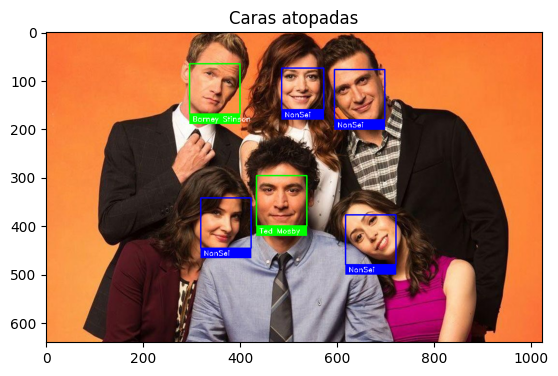

In [28]:
face_names = []

dets = detector(imaxeTodosColor, 0)
tolerancia = 0.60
for d in dets:

    shape = sp(imaxeTodosColor,d)
    vector_desconocido = np.array(facerec.compute_face_descriptor(imaxeTodosColor, shape))

    matches = [] # Lista temporal para guardar las coincidencias de esta cara concreta
    for index, fila in leido.iterrows():
        nombre_conocido = fila['nome']
        vector_conocido = fila['f2']        
        # Calculamos la distancia (la diferencia matemática)
        distancia = np.linalg.norm(vector_conocido - vector_desconocido)

        #Si la distancia es menor o igual a 0.6, lo guardamos como un "match"
        if distancia <= tolerancia:
            # Guardamos la tupla (distancia, Nombre)
            matches.append((distancia, nombre_conocido))
        
        print(f"Posibles coincidencias para esta cara: {matches}")
        
        if len(matches) == 0:
            face_names.append(((d.top(), d.right(), d.bottom(), d.left()),"NonSei"))
        else:
            carasOrdenadas = sorted(matches,key=lambda x: x[0])
            # Nos quedamos con el nombre del mejor resultado (el índice 0)
            mejor_nombre = carasOrdenadas[0][1]
            face_names.append(((d.top(), d.right(), d.bottom(), d.left()), mejor_nombre))
imaxeConMarcas = imaxeTodosColor.copy() 
for (top, right, bottom, left), name in face_names:
    # Scale back up face locations since the frame we detected in was scaled to 1/4 size

    color = (0, 255, 0)
    if name=="NonSei":
        color = (0, 0, 255)
    # Draw a box around the face
    cv2.rectangle(imaxeConMarcas, (left, top), (right, bottom), color, 2)

    # Draw a label with a name below the face
    cv2.rectangle(imaxeConMarcas, (left, bottom + 20), (right, bottom), color, cv2.FILLED)
    font = cv2.FONT_HERSHEY_DUPLEX
    cv2.putText(imaxeConMarcas, name, (left + 6, bottom + 15), font, 0.5, (255, 255, 255), 1)

plt.imshow(imaxeConMarcas)
plt.title('Caras atopadas')
plt.show()      